In [188]:
import math
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

from scipy import stats 

import dilutionUtils as dil
%matplotlib inline

In [2]:
# DONT RUN - this isn't ready yet
#files, injection, calibration = dil.load_config("./dil_config.ini")

In [3]:
# Configuration Parameters
# constants
rho_salt = 2.165 # density of NaCl in g/cm^3

# file operations
csv_folder ="./output"
search_0709 = "20250709_*_790478.csv"
search_0724 = "20250724_*.csv"
calibration_0709 = './20250709_trial2_calibration.csv'


# injection
Vo = 13000 # ml of H20 collected stream on 07/15
mass_salt = 4000 # g

# calibration
vol_calibration_sample = 100 # ml
Vnew = Vo +  mass_salt / rho_salt # ml
vol_solution_injected = Vnew - vol_calibration_sample # ml
injection_conc = (mass_salt) / (Vo) # g/cm^3

print(injection_conc)

0.3076923076923077


In [4]:

csv_list = dil.get_file_paths(csv_folder, search_0724)
csv_list

['./output/20250724_162611_840058.csv',
 './output/20250724_172044_680530_calibration.csv',
 './output/20250724_trial1_solution_injection_calibration.csv']

In [5]:
ec_data_trial_1 = dil.extract_fields(dil.read_csv(csv_list[0]))

In [ ]:
# Add to utils
# Plot all datasets in the csv_list with a shared x-axis
# make a version that doesn't share axis
time_col = 'Date Time'
y_col = 'Actual Conductivity (µS/cm)' # make this find the conductivity column for different loggers
files = csv_list[:2]
n_files = len(files)

# Create subplots: one row per file
fig, axs = plt.subplots(nrows=n_files, ncols=1, figsize=(12, 3 * n_files), sharex=False)

# Flatten axs if needed (only necessary if n_files == 1, otherwise it's already iterable)
if n_files == 1:
    axs = [axs]

# Loop through files and axes
for ax, filepath in zip(axs, files):
    # Read CSV
    df = pd.read_csv(filepath)

    # Convert Date Time column - using the index as time value
    df[time_col] = pd.to_datetime(df[time_col], errors='coerce')
    df = df.dropna(subset=[time_col, y_col])

    # Plot by index not time
    ax.plot(df[time_col], df[y_col], color='blue')

    # Format subplot
    filename = filepath.split('\\')[-1]
    ax.set_title(filename)
    ax.set_ylabel('Actual Conductivity (µS/cm)')
    ax.grid(True)

# Global x label
plt.xlabel('Time')

# Layout
plt.tight_layout()
plt.show()

In [7]:
calibration_csv = dil.read_csv(csv_list[2])
calibration_data = dil.extract_fields(calibration_csv)
#uncomment the line below if you want to see the calibraton dictionary
calibration_data.keys()

dict_keys(['Calibration_volume_ml', 'Additions_of_secondary_ml', 'Cumulative_secondary_solution_ml', 'Conductivity'])

In [8]:
# this is for 07/24 data
# pylance doesn't like this - figure out how to make better
Vo = calibration_data['Calibration_volume_ml'][0]
Vadd = calibration_data['Additions_of_secondary_ml']
RC_ss = dil.secondary_solution_RC(vol_solution_injected, Vo=Vo)
RC = dil.calibration_RC(RC_sec=RC_ss,additions_of_injection=Vadd,Vc=Vo)
slope_k = dil.calculate_k(RC_values=RC,EC_values=calibration_data['Conductivity'])
print(f"{Vo}\n{Vadd}\n{RC_ss}\n{RC}\n{slope_k}")

3000.0
[0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
0.8309628222311866
[0.0, 0.0002768953089740708, 0.0005536061440580857, 0.0008301326895416448, 0.0011064751294689568, 0.0013826336476392455, 0.0016586084276071587, 0.0019343996526831745, 0.002210007505934007, 0.0024854321701830106, 0.0027606738280105863, 0.003035732661754584, 0.003310608853510703, 0.0035853025851328994]
0.00013544777427778237


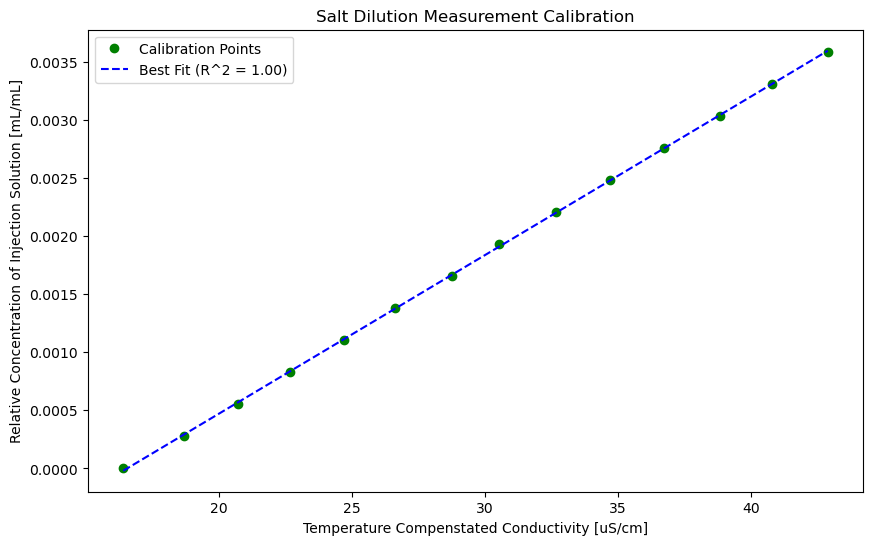

In [9]:
# this is for the 24th
# initialize a single figure (the values 1, 1 can be changed to create a grid of plots)
fig, ax = plt.subplots(1, 1, figsize=(10,6))

# the .to_numpy() attribute converts to a vector in order to do vector operations
cond_series = np.array(calibration_data['Conductivity'])
conc_series = np.array(RC)

# add the calibration points to the plot
ax.plot(cond_series, conc_series, 'go', label="Calibration Points")

ax.set_xlabel('Temperature Compenstated Conductivity [uS/cm]')
ax.set_ylabel('Relative Concentration of Injection Solution [mL/mL]')
ax.set_title('Salt Dilution Measurement Calibration')

# add best fit line
results = stats.linregress(cond_series, conc_series)
# the stats.linregress output is a 5-tuple, r_value is the correlation coefficient
slope, intercept, r_value, p_value, std_err = results

#  create an array between the minimum and maximum calibration points
x_range = np.linspace(cond_series.min(), cond_series.max(),  100)

# use the best fit slope and intercept to construct the best fit line
best_fit = [x * slope + intercept for x in x_range]

# add the best fit line to the plot
ax.plot(x_range, best_fit, 'b--', label='Best Fit (R^2 = {:.2f})'.format(math.pow(r_value,2)))
# by default a legend is not shown, so we need to call the attribute.
plt.legend()

In [10]:
#note: the number of decimals in the slope is too low. adjust the line below to print one more decimal.
print(f"The calibration best fit slope is {slope:.10f} [[mg/mL] / [uS/cm]]")
print(f"The coefficient of determination of the calibration is {r_value**2:.3f}.")

The calibration best fit slope is 0.0001365880 [[mg/mL] / [uS/cm]]
The coefficient of determination of the calibration is 1.000.


In [ ]:

bg_start = "16:26:11"#time(16,26,11)
bg_end = "16:29:00"#time(16,27,14)
trial_start = "16:30:00"
trial_end = "16:35:57"
record_end = "16:37:54"
bg_sec = dil.time_diff_sec(bg_start,trial_start)
trial_sec = dil.time_diff_sec(trial_start,trial_end)
total_sec = dil.time_diff_sec(bg_start,record_end)
print(total_sec, bg_sec, trial_sec)

In [ ]:
# not sure if I need this
result = dil.get_measurement_values(
    bg_start_time_str=bg_start,
    bg_end_time_str=trial_start,
    trial_start_time_str=trial_start,
    trial_end_time_str=trial_end,
    data=ec_data_trial_1,
    show_data=True
    )
if result is not None:
    background_ec, bg_time, trial_ec, trial_time = result

In [ ]:
# time difference between readings (diff) is one.
# Cumm is cumulative time during trial
bg_diff, bg_cumm = dil.compute_time_differences_in_seconds(bg_time)
total_diff, total_cumm = dil.compute_time_differences_in_seconds(ec_data_trial_1['Date Time'])
trial_diff, trial_cumm = dil.compute_time_differences_in_seconds(trial_time)

In [ ]:
# this is for plotting the background value
bg_value = dil.get_background_ec(0,bg_sec,background_ec)
# casting the background value to an array using an array of ones (which happens to be the difference array)
bg_values = bg_value * np.array(total_diff)

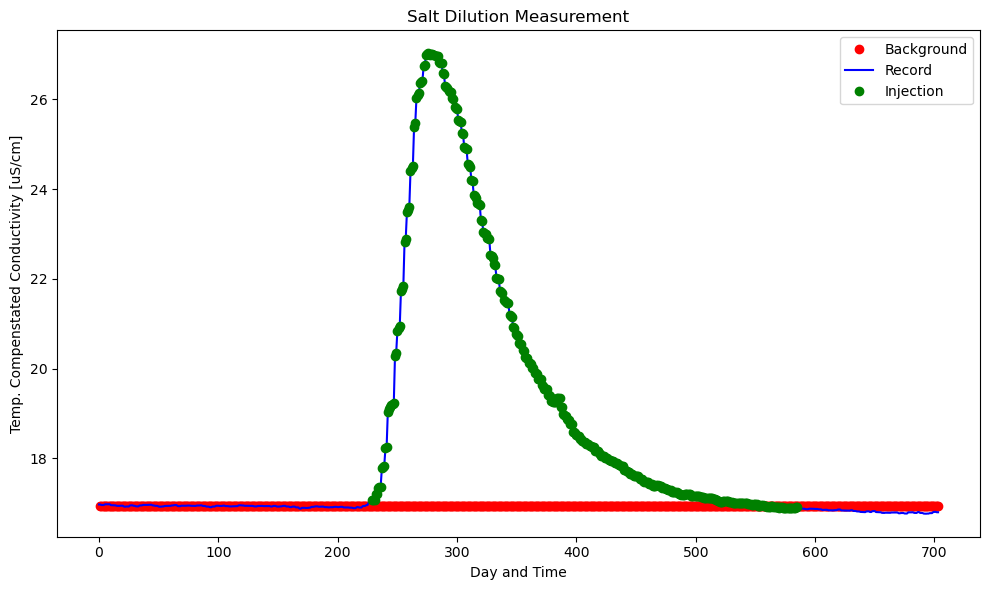

In [ ]:
# change the show_background boolean to plot just the EC data.
# Or different parts of the experiment (background period, injection period)
show_background = True
fig, ax = plt.subplots(1, 1, figsize=(10,6))
ec_data = ec_data_trial_1['Actual Conductivity (µS/cm)']
if show_background == True:
        ax.plot(total_cumm[1:], bg_values, 'ro',label='Background')

        ax.plot(total_cumm,ec_data, color='blue', label='Record')

        ax.plot(total_cumm[bg_sec:trial_sec], 
                ec_data[bg_sec:trial_sec], 'go',
                label='Injection')
else:
        ax.plot(total_cumm,ec_data, color='blue', label='Record')


# label the axes, and set the plot title
ax.set_xlabel('Day and Time')
ax.set_ylabel('Temp. Compenstated Conductivity [uS/cm]')
ax.set_title('Salt Dilution Measurement')
plt.legend()
plt.tight_layout()

In [ ]:
def calculate_Q(ec_bg, ec_data, slope, time_step, injection_volume):
    data = np.array(ec_data)
    ec_diff = (data - ec_bg) * slope
    BTC_area = np.sum(np.multiply(ec_diff, time_step))
    vol_m3 = injection_volume / 1000000 # convert ml to m^3
    Q = vol_m3 / BTC_area
    return Q

In [189]:
Q = calculate_Q(
    ec_bg=bg_value,
    ec_data=ec_data[bg_sec:trial_sec],
    slope=slope_k,
    time_step=total_diff[bg_sec:trial_sec],
    injection_volume=vol_solution_injected
)
Q

np.float64(112045.52409271277)